# Extração e medida de desalinhamento do BAG

Implementação do artigo:

[1] W. Li, Y. Yuan, e N. Yu, “Passive detection of doctored JPEG image via block artifact grid extraction”, Signal Processing, vol. 89, nº 9, p. 1821–1829, set. 2009, doi: 10.1016/j.sigpro.2009.03.025.

Autor: Paulo Max Gil Innocencio Reis 

Email: paulo.pmgir@pf.gov.br

Serviço de Perícias em Audiovisual e Eletrônicos - INC/DITEC

*Edições podem deixar criar desalinhamentos no BAG, ou perturbá-lo

## Importa Pacotes e define função de processamento em blocos

In [1]:
import cv2
import numpy as np
from scipy.ndimage import convolve
from scipy.signal import medfilt2d

# Função BlockValue otimizada para processamento por blocos
def BlockValue(blocks):
    blockData = blocks.reshape(blocks.shape[0], blocks.shape[1], 8, 8)
    Max1 = np.max(np.sum(blockData[:, :, 1:7, 1:7], axis=3), axis=2)
    Min1 = np.min(np.sum(blockData[:, :, 1:7, [0, 7]], axis=3), axis=2)
    Max2 = np.max(np.sum(blockData[:, :, 1:7, 1:7], axis=2), axis=2)
    Min2 = np.min(np.sum(blockData[:, :, [0, 7], 1:7], axis=2), axis=2)
    return Max1 - Min1 + Max2 - Min2




## Carregar a imagem de trabalho

In [15]:
# Carregar a imagem
im = cv2.imread('Ex3.jpg')

## Extração do BAG

In [16]:

# Verificar as dimensões da imagem
height, width, channels = im.shape
# Calcular o padding necessário
pad_height = (8 - (height % 8)) % 8
pad_width = (8 - (width % 8)) % 8
# Realizar o padding
if pad_height > 0 or pad_width > 0:
    im = np.pad(im, ((0, pad_height), (0, pad_width), (0, 0)), mode='constant', constant_values=0)

# Converter RGB para YCbCr
YCbCr = cv2.cvtColor(im, cv2.COLOR_BGR2YCrCb)
Y = YCbCr[:, :, 0].astype(float)

# Parâmetros
DiffThresh = 50
AC = 33

# Cálculo das diferenças verticais (Y)
Im2DiffY = -np.diff(np.vstack([Y[0, :], Y, Y[-1, :]]), n=2, axis=0)
Im2DiffY[np.abs(Im2DiffY) > DiffThresh] = 0
padded = np.pad(Im2DiffY, ((0, 0), (round((AC-1)/2), round((AC-1)/2))), mode='symmetric')
summedH = convolve(np.abs(padded), np.ones((1, AC)), mode='constant', cval=0.0)
summedH = summedH[:, round((AC-1)/2):-round((AC-1)/2)]
mid = medfilt2d(summedH, kernel_size=(AC, 1))
eH = summedH - mid
paddedHorz = np.pad(eH, ((16, 16), (0, 0)), mode='symmetric')

# /media/paulopmgir/HD3T/VE-OctaveMatlab/BLK_OCT/demo.jpgConstrução da matriz HorzMid
HorzMid = np.zeros((paddedHorz.shape[0] - 32, paddedHorz.shape[1], 5))
HorzMid[:, :, 0] = paddedHorz[0:-32, :]
HorzMid[:, :, 1] = paddedHorz[8:-24, :]
HorzMid[:, :, 2] = paddedHorz[16:-16, :]
HorzMid[:, :, 3] = paddedHorz[24:-8, :]
HorzMid[:, :, 4] = paddedHorz[32:, :]
HorzMid = np.median(HorzMid, axis=2)

# Cálculo das diferenças horizontais (X)
Im2DiffX = -np.diff(np.hstack([Y[:, 0].reshape(-1, 1), Y, Y[:, -1].reshape(-1, 1)]), n=2, axis=1)
Im2DiffX[np.abs(Im2DiffX) > DiffThresh] = 0
padded = np.pad(Im2DiffX, ((round((AC-1)/2), round((AC-1)/2)), (0, 0)), mode='symmetric')
summedV = convolve(np.abs(padded), np.ones((AC, 1)), mode='constant', cval=0.0)
summedV = summedV[round((AC-1)/2):-round((AC-1)/2), :]
mid = medfilt2d(summedV, kernel_size=(1, AC))
eV = summedV - mid
paddedVert = np.pad(eV, ((0, 0), (16, 16)), mode='symmetric')

# Construção da matriz VertMid
VertMid = np.zeros((paddedVert.shape[0], paddedVert.shape[1] - 32, 5))
VertMid[:, :, 0] = paddedVert[:, 0:-32]
VertMid[:, :, 1] = paddedVert[:, 8:-24]
VertMid[:, :, 2] = paddedVert[:, 16:-16]
VertMid[:, :, 3] = paddedVert[:, 24:-8]
VertMid[:, :, 4] = paddedVert[:, 32:]
VertMid = np.median(VertMid, axis=2)

# Cálculo da diferença de blocos
BlockDiff = HorzMid + VertMid



## Processamento em blocos para métrica de desalinhamento

In [17]:
from skimage.util import view_as_blocks
# Processamento por blocos usando view_as_blocks e aplicando BlockValue
block_size = (8, 8)
blocks = view_as_blocks(BlockDiff, block_size)
b = BlockValue(blocks)


b = b.repeat(8, axis=0).repeat(8, axis=1)


## Mapa de métricas de desalinamento

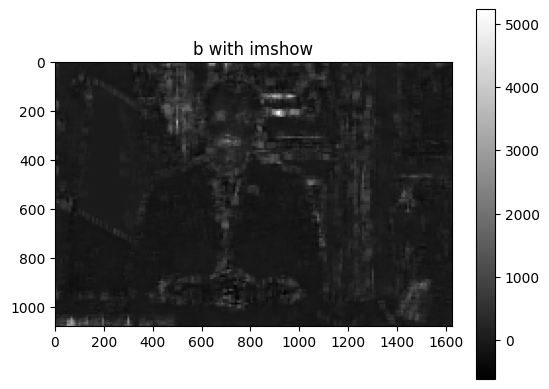

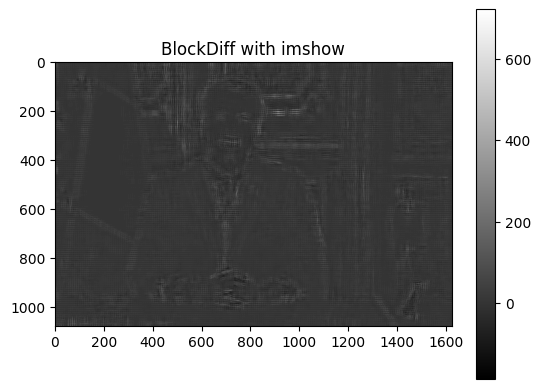

In [18]:
import matplotlib.pyplot as plt

# Plotando 'b' usando imshow com escala ajustada
plt.figure(1)
plt.imshow(b, cmap='gray')
plt.title('b with imshow')
plt.colorbar()
plt.show()

# Plotando 'BlockDiff' usando imshow com escala ajustada
plt.figure(3)
plt.imshow(BlockDiff, cmap='gray')
plt.title('BlockDiff with imshow')
plt.colorbar()
plt.show()